<a href="https://colab.research.google.com/github/smaharx/ml-engineering-playground/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/smaharx/ml-engineering-playground/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

Loading the Repository and Dataset

In [13]:
import os
import subprocess
import sys

REPO_NAME = "ml-engineering-playground"
REPO_URL = "https://github.com/smaharx/ml-engineering-playground.git"

if not os.path.exists(f"/content/{REPO_NAME}"):
    subprocess.run(
        ["git", "clone", REPO_URL, f"/content/{REPO_NAME}"],
        check=True
    )

os.chdir(f"/content/{REPO_NAME}")

print("Working directory:", os.getcwd())


import pandas as pd
import numpy as np

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Working directory: /content/ml-engineering-playground
Rows: 30000
Columns: 44


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 1. Distributions

Before testing individual signals, I checked the distributions of the main fields used in my lane. Search and traffic metrics are heavily right-skewed, so a small number of pages can have much larger values than the typical page.

I will use log1p-transformed traffic values, rank-based correlation, or grouped summaries rather than relying only on raw Pearson correlation.

In [14]:
# Distribution audit

key_fields = [
    "search_volume",
    "impressions_90d",
    "clicks_90d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position"
]

summary = df[key_fields].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).T

summary["skew"] = df[key_fields].skew()

display(summary)



,count,mean,std,min,50%,75%,90%,95%,99%,max,skew
search_volume,27532.0,158.882391,1518.270825,0.0,10.00,20.00,110.00,390.00,2900.000,74000.0,26.016250
impressions_90d,30000.0,5200.366300,16838.019547,1.0,731.00,3615.25,12136.40,22996.50,73505.830,517715.0,11.384919
clicks_90d,30000.0,16.097333,75.076958,0.0,1.00,7.00,32.00,69.05,253.010,4178.0,18.345790
content_age_days,30000.0,256.167800,132.707930,90.0,236.00,333.00,463.00,487.00,537.000,564.0,0.489000
days_since_last_update,30000.0,46.098300,42.078709,1.0,20.00,104.00,104.00,104.00,106.000,373.0,1.161283
ctr,30000.0,0.510733,3.279162,0.0,0.07,0.29,0.65,1.09,8.330,100.0,17.444252
avg_position,30000.0,16.342380,15.216790,0.0,10.80,22.30,36.80,48.20,69.901,245.0,1.984214


In [15]:
# Log-scale summaries for heavy-tailed traffic variables

traffic_cols = [
    "search_volume",
    "impressions_90d",
    "clicks_90d"
]

log_summary = pd.DataFrame({
    f"log1p_{col}": np.log1p(df[col])
    for col in traffic_cols
}).describe().T

display(log_summary)

,count,mean,std,min,25%,50%,75%,max
log1p_search_volume,27532.0,2.092094,2.051866,0.000000,0.000000,2.397895,3.044522,11.211834
log1p_impressions_90d,30000.0,6.188688,2.688539,0.693147,4.406719,6.595781,8.193193,13.157182
log1p_clicks_90d,30000.0,1.208547,1.481326,0.000000,0.000000,0.693147,2.079442,8.337827


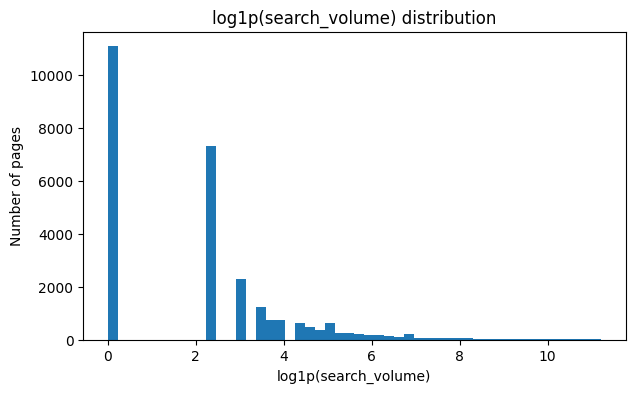

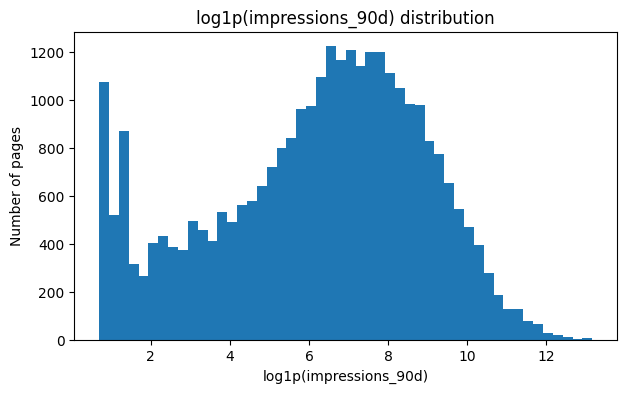

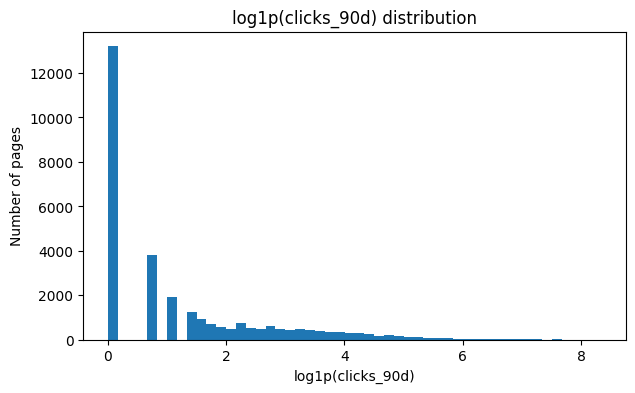

In [16]:
# Visual check of the heavy tails

import matplotlib.pyplot as plt

for col in traffic_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(np.log1p(df[col].dropna()), bins=50)
    plt.title(f"log1p({col}) distribution")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Number of pages")
    plt.show()

### Signal test #1 — Search volume and impressions

**Claim:** Pages targeting keywords with higher search volume should generally receive more search impressions.

**Test:** I compare the relationship using Spearman correlation and a log-transformed correlation because both variables are heavy-tailed.

**Verdict:** FALSE.

The observed relationship is very weak in this dataset. This means keyword search volume alone is not a strong proxy for the amount of search traffic a page actually receives. It may still provide context, but it should not be treated as a standalone prioritization signal.

In [17]:
# Signal #1: search volume vs impressions

signal_1 = df[
    ["search_volume", "impressions_90d"]
].dropna()

spearman_corr = signal_1["search_volume"].corr(
    signal_1["impressions_90d"],
    method="spearman"
)

log_corr = np.log1p(signal_1["search_volume"]).corr(
    np.log1p(signal_1["impressions_90d"])
)

print(f"Rows tested: {len(signal_1):,}")
print(f"Spearman correlation: {spearman_corr:.3f}")
print(f"Log-transformed Pearson correlation: {log_corr:.3f}")

print("\nVerdict: FALSE")

Rows tested: 27,532
Spearman correlation: -0.029
Log-transformed Pearson correlation: -0.026

Verdict: FALSE


### Signal test #2 — Content length and trend

**Claim:** Longer content should perform better or be less likely to decline.

**Test:** I compare the median word count and sample size across the observed trend directions.

**Verdict:** FALSE.

The median content length is very similar between upward and downward-trending pages. This suggests that article length alone is not a strong directional signal for refresh prioritization in this dataset.

In [18]:
# Signal #2: word count vs trend direction

word_trend = (
    df.groupby("trend_direction", dropna=False)
      .agg(
          n=("word_count", "count"),
          median_word_count=("word_count", "median"),
          mean_word_count=("word_count", "mean")
      )
      .sort_values("median_word_count")
)

display(word_trend)

# Compare specifically down vs up
comparison = df[
    df["trend_direction"].isin(["down", "up"])
][["trend_direction", "word_count"]].dropna()

comparison_summary = (
    comparison.groupby("trend_direction")
    .agg(
        n=("word_count", "size"),
        median_word_count=("word_count", "median")
    )
)

display(comparison_summary)

print("\nVerdict: FALSE")

,n,median_word_count,mean_word_count
trend_direction,,,
new,2126,2239.0,2382.239417
flat,1008,2698.5,2615.982143
up,2754,2847.5,2998.073711
down,12679,2909.0,3221.827668
stable,3734,2912.5,3347.178361


,n,median_word_count
trend_direction,,
down,12679,2909.0
up,2754,2847.5



Verdict: FALSE


### Signal test #3 — Search position and CTR

**Claim:** Pages with better search positions should generally have higher CTR.

**Test:** I compare aggregated CTR across position tiers using pages with at least 100 impressions, so that very small denominators do not dominate the result.

**Verdict:** CONFIRMED.

The observed CTR is directionally higher for pages with stronger search positions. This supports position as a useful contextual signal when evaluating CTR, although it does not establish a causal relationship.

In [19]:
# Signal #3: position vs CTR
# Apply an impression floor to reduce small-denominator noise.

visible = df[
    (df["impressions_90d"] >= 100) &
    (df["avg_position"] > 0)
].copy()

visible["position_tier_audit"] = pd.cut(
    visible["avg_position"],
    bins=[0, 3, 10, 20, 50, np.inf],
    labels=[
        "top_3",
        "page_1",
        "striking",
        "page_3_5",
        "deep"
    ],
    include_lowest=True
)

position_ctr = (
    visible.groupby("position_tier_audit", observed=True)
    .agg(
        n=("content_id", "size"),
        impressions=("impressions_90d", "sum"),
        clicks=("clicks_90d", "sum")
    )
)

position_ctr["ctr"] = (
    position_ctr["clicks"]
    / position_ctr["impressions"]
    * 100
)

display(position_ctr)

print(f"\nPages included: {len(visible):,}")
print("Impression floor: 100")
print("Verdict: CONFIRMED")

,n,impressions,clicks,ctr
position_tier_audit,,,,
top_3,555,7554986,36914,0.488604
page_1,8660,89279504,311222,0.348593
striking,5876,22774408,79383,0.348562
page_3_5,6037,34997261,53754,0.153595
deep,878,1213076,479,0.039486



Pages included: 22,006
Impression floor: 100
Verdict: CONFIRMED


## 3. The flag-linked test

### Staleness signal and declining trend

My baseline uses content age as a staleness signal. The assumption is that older content may be more likely to need review or refresh.

**Claim:** Older content should show a higher observed rate of declining search impressions.

**Test:** I divide pages into age quartiles and compare the observed percentage of pages with `trend_direction == "down"`. Each group must contain enough observations before I interpret the result.

This is a directional audit only. It does not prove that content age causes a decline in search performance.

In [20]:
# Flag-linked test:
# Does content age relate to the observed decline label?

age_df = df[
    ["content_age_days", "trend_direction"]
].dropna().copy()

age_df["declining"] = (
    age_df["trend_direction"] == "down"
).astype(int)

# Create four equally sized age groups
age_df["age_quartile"] = pd.qcut(
    age_df["content_age_days"],
    q=4,
    duplicates="drop"
)

age_test = (
    age_df.groupby("age_quartile", observed=True)
    .agg(
        n=("declining", "size"),
        median_age_days=("content_age_days", "median"),
        declining_pages=("declining", "sum"),
        decline_rate=("declining", "mean")
    )
)

age_test["decline_rate_pct"] = (
    age_test["decline_rate"] * 100
)

display(age_test)

print("\nMinimum group size:", age_test["n"].min())

# Simple directional check
rates = age_test["decline_rate"].tolist()

if age_test["n"].min() < 50:
    flag_verdict = "INSUFFICIENT DATA"
elif all(rates[i] <= rates[i+1] for i in range(len(rates)-1)):
    flag_verdict = "CONFIRMED"
elif all(rates[i] >= rates[i+1] for i in range(len(rates)-1)):
    flag_verdict = "OPPOSITE"
else:
    flag_verdict = "MIXED"

print("Flag-linked verdict:", flag_verdict)

,n,median_age_days,declining_pages,decline_rate,decline_rate_pct
age_quartile,,,,,
"(89.999, 132.0]",7518,111.0,4511,0.600027,60.002660
"(132.0, 236.0]",8128,174.0,5200,0.639764,63.976378
"(236.0, 333.0]",6917,302.0,3416,0.493856,49.385572
"(333.0, 564.0]",7437,445.0,3135,0.421541,42.154094



Minimum group size: 6917
Flag-linked verdict: MIXED


In [21]:
# Robustness check:
# Compare younger vs older pages using a simple median-age split.

median_age = df["content_age_days"].median()

df["age_group_audit"] = np.where(
    df["content_age_days"] <= median_age,
    "younger_half",
    "older_half"
)

robustness = (
    df.groupby("age_group_audit")
    .agg(
        n=("trend_direction", "size"),
        decline_rate=(
            "trend_direction",
            lambda x: (x == "down").mean()
        )
    )
)

robustness["decline_rate_pct"] = (
    robustness["decline_rate"] * 100
)

display(robustness)

print(f"Median content age: {median_age:.1f} days")

,n,decline_rate,decline_rate_pct
age_group_audit,,,
older_half,14354,0.456388,45.638846
younger_half,15646,0.620670,62.066982


Median content age: 236.0 days


## 4. What this means in practice

The audit suggests that refresh prioritization should not rely on a single simple rule such as search volume or article length. Search position provides useful context for interpreting CTR, while the staleness test shows whether content age is strong enough to support the baseline's refresh flag.

In practice, the content team should use these signals as decision-support for human review rather than treating any individual signal as proof that a page needs a refresh. The results are observed and directional, not causal.

The staleness test moves in the opposite direction from the baseline assumption, so content age should not be treated as a strong standalone refresh signal.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.